In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from matplotlib.colors import to_rgb


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)

# dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio.pkl')

sample_eddies = [100, 627, 1269, 2609, 34, 281, 2334, 3126]

# dic_sample = {}
# for eddy in sample_eddies:
#     if eddy is not np.nan:
#         eddy = f'Eddy{eddy}'
#         dic_sample[eddy] = dic_vert[eddy]

dic_sample = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio_sample.pkl')
        

In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

# Unique colors for each eddy
colors = [c for i, c in enumerate(plt.get_cmap("tab10").colors) if i != 7]


Text(0, 0.5, 'Latitude (°N)')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


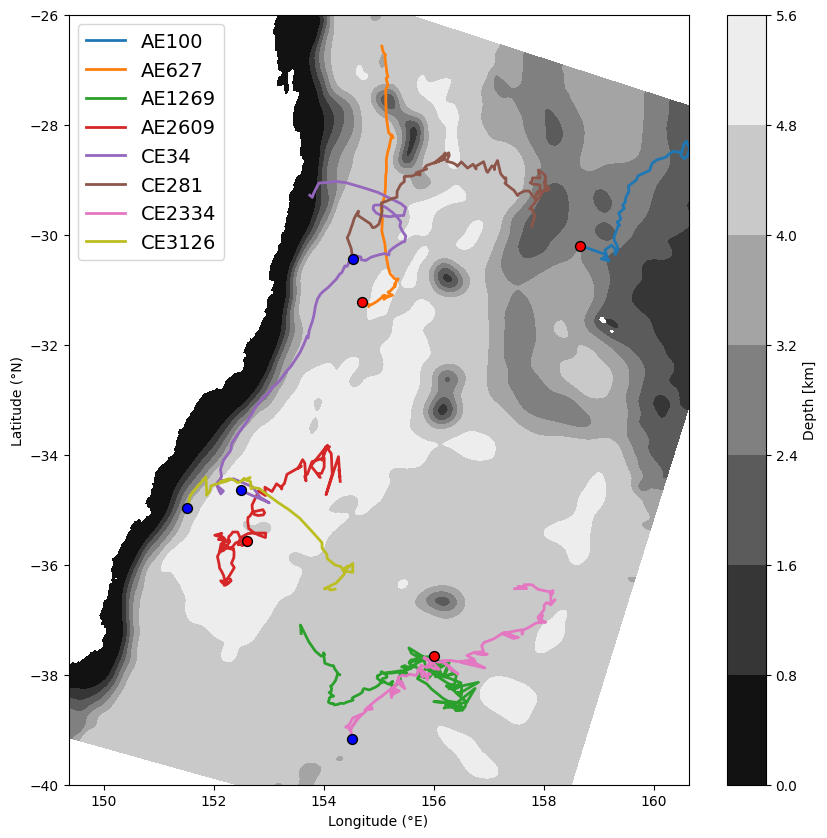

In [4]:
plt.figure(figsize=(10,10))
plt.contourf(lon_rho, lat_rho, np.where(mask_rho, h, np.nan)/1000, cmap='gray')
plt.colorbar(label='Depth [km]')

for e, eddy in enumerate(sample_eddies):

    df = df_eddies[df_eddies.Eddy==eddy].copy()
    cyc = df.iloc[0].Cyc
    plt.plot(df['lon'], df['lat'], label=f'{cyc}{eddy}',
            linewidth=2, color=colors[e%len(colors)])
    plt.scatter(df.iloc[-1]['lon'], df.iloc[-1]['lat'], edgecolors='k',
                color='r' if cyc=='AE' else 'b', zorder=10, s=50)

plt.legend(loc='upper left', fontsize=14)
plt.axis('equal')
plt.xlim(150, 160)
plt.ylim(-40, -26)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')


#### Side Profiles

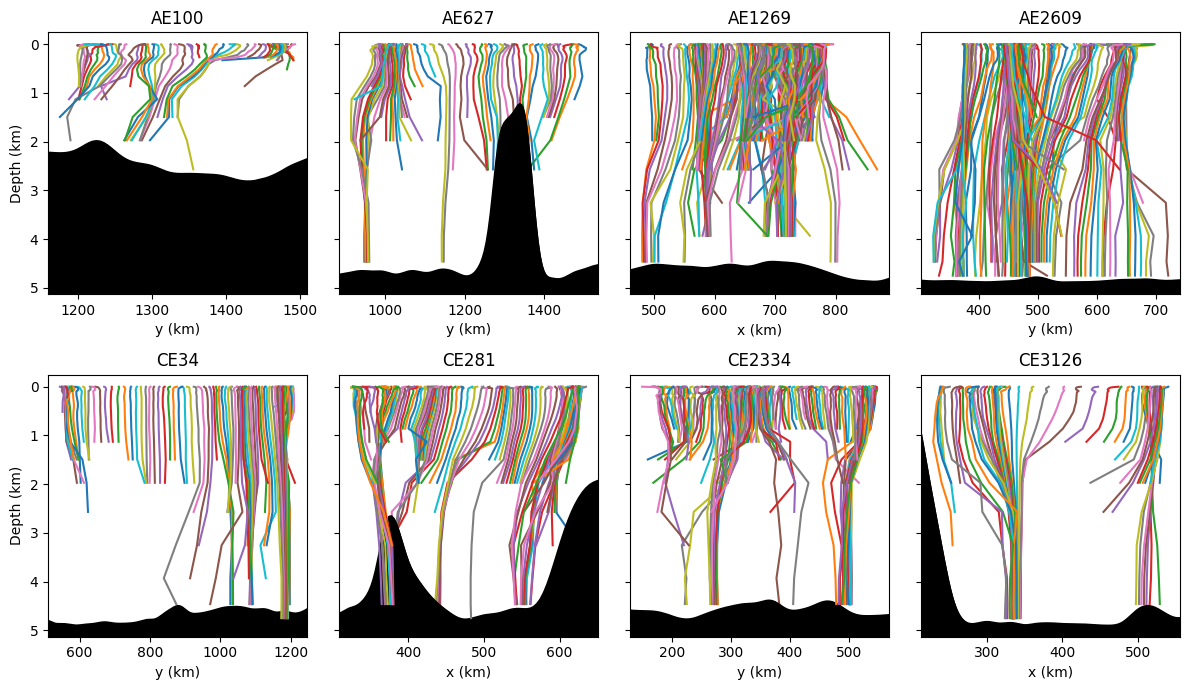

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(12,7), sharey=True)
for e, eddy in enumerate(sample_eddies):
    ax = axs[e // 4, e % 4]
    if eddy in [3126, 1269, 281]:
        flagx = True
    else:
        flagx = False
    days = dic_sample[f'Eddy{eddy}']
    df_all = pd.concat(
        [df0 for df0 in days.values() if not df0.empty and not df0.isna().all().all()],
        ignore_index=True
    )
    df_mean = pd.DataFrame([{
        'Eddy': eddy,
        'x_mean': df_all['xc'].mean(),
        'y_mean': df_all['yc'].mean()
    }])
    
    dic = dic_sample[f'Eddy{eddy}']
    pmean = df_mean[df_mean.Eddy==eddy].iloc[0]
    for d, day in enumerate(dic.keys()):
        df = dic[day].copy()
        if len(df):
            if flagx:
                ax.plot(df.xc, df.Depth.abs()/1e3, zorder=0 if df.iloc[-1].yc > pmean.y_mean else 2)
                ax.set_xlabel('x (km)')
            else:
                ax.plot(df.yc, df.Depth.abs()/1e3, zorder=2 if df.iloc[-1].xc > pmean.x_mean else 0)
                ax.set_xlabel('y (km)')
    xlim = ax.get_xlim()

    if flagx:
        jc = np.where(np.abs(pmean.y_mean-y_grid)==np.min(np.abs(pmean.y_mean-y_grid)))[0][0]
        ax.plot(x_grid, h[:, jc]/1000, 'k', zorder=1)
        ylim = ax.get_ylim()
        ax.fill_between(x_grid, h[:, jc] / 1000, 10, color='k', zorder=1)
    else:
        ic = np.where(np.abs(pmean.x_mean-x_grid)==np.min(np.abs(pmean.x_mean-x_grid)))[0][0]
        ax.plot(y_grid, h[ic, :]/1000, 'k', zorder=1)
        ylim = ax.get_ylim()
        ax.fill_between(y_grid, h[ic, :] / 1000, 10, color='k', zorder=1)
    
    cyc = df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc
    ax.set_title(f'{cyc}{eddy}')
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
axs[0,0].set_ylabel('Depth (km)')
axs[1,0].set_ylabel('Depth (km)')
axs[0,0].invert_yaxis()
plt.tight_layout()


#### Depths

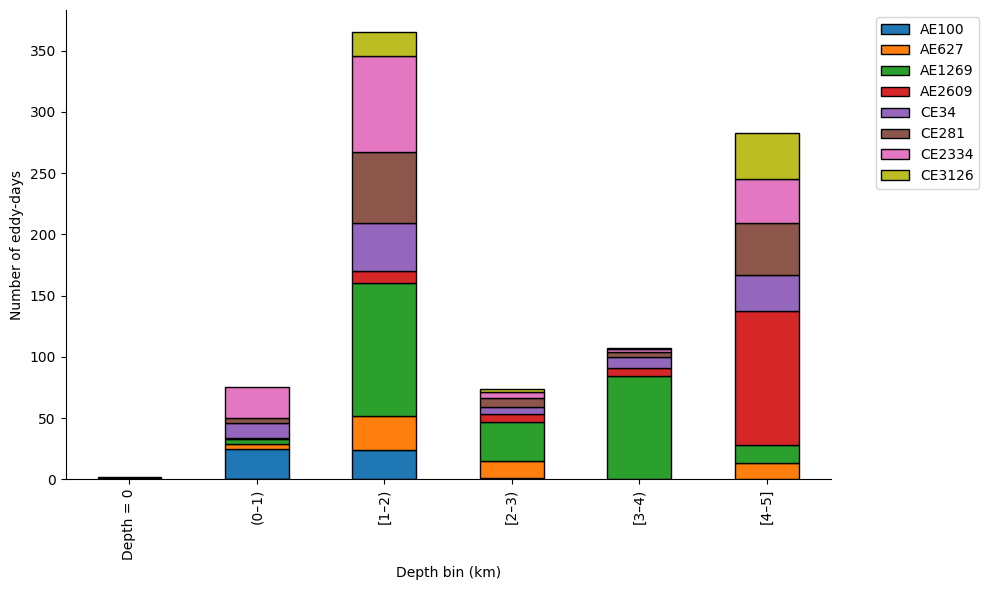

In [6]:
# Adjustable bin width
bin_width = 1  # km
max_depth_km = 5  # adjust as needed

# Create bin edges
edges = np.arange(0, max_depth_km + bin_width, bin_width)

# Labels: Depth=0 | (0–1) | [1–2) ... [4–5]
def _fmt(x):
    return f"{x:.0f}" if float(bin_width).is_integer() else f"{x:.1f}"

bin_labels = (["Depth = 0",
               f"({_fmt(edges[0])}–{_fmt(edges[0] + bin_width)})"]
              + [f"[{_fmt(b)}–{_fmt(b+bin_width)})" for b in edges[1:-1]])
bin_labels[-1] = f"[{_fmt(edges[-2])}–{_fmt(edges[-1])}]"

# Prepare DataFrame
eddies = [int(eddy[4:]) for eddy in list(dic_sample.keys())]
cycs = []
for eddy in eddies:
    cycs.append(df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc)
eddy_names = [cycs[k]+str(eddies[k]) for k in range(len(eddies))]

bin_counts = pd.DataFrame(0, index=bin_labels, columns=eddy_names)

# Fill in counts
for e, eddy in enumerate(eddy_names):
    if pd.isna(eddy):
        continue
    dic = dic_sample[f'Eddy{eddy[2:]}']
    depths = []
    for day in dic:
        df = dic[day].copy()
        if len(df):
            depth_km = np.abs(df.iloc[-1]['Depth']) / 1000
            depths.append(depth_km)
        else:
            depths.append(0)

    depths = np.array(depths)

    # Separate exact zeros so they don’t get included in (0–1)
    zero_count = np.isclose(depths, 0).sum()
    nonzero = depths[~np.isclose(depths, 0)]

    counts, _ = np.histogram(nonzero, bins=edges)
    counts = np.insert(counts, 0, zero_count)  # prepend Depth=0 bin
    bin_counts.loc[:, eddy] = counts

# Plot
bin_counts.plot(kind='bar', stacked=True, figsize=(10, 6),
                edgecolor='black', color=colors)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel('Depth bin (km)')
plt.ylabel('Number of eddy-days')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


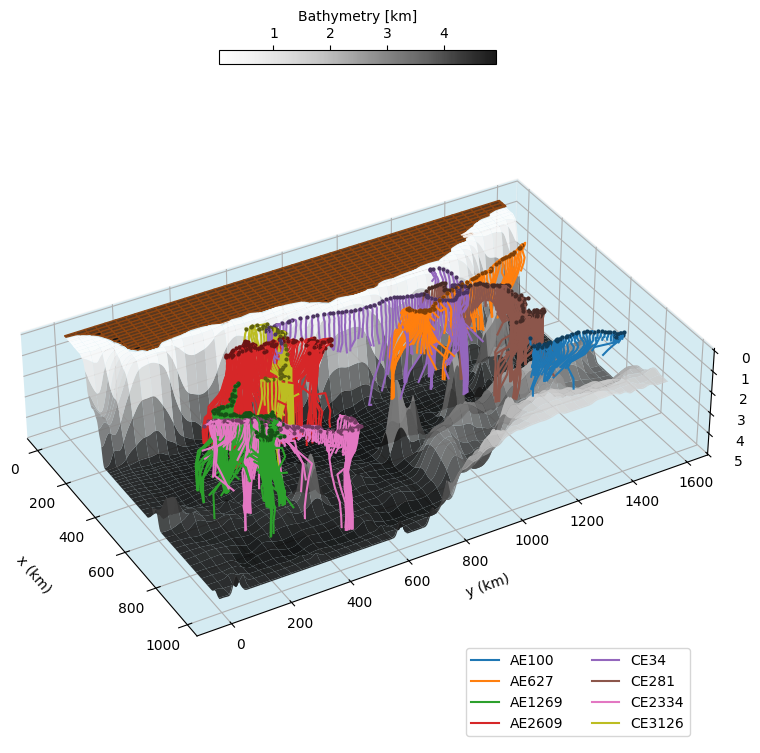

In [7]:
def darken(color, factor=0.7):
    r, g, b = to_rgb(color)
    return (r*factor, g*factor, b*factor)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

ax.xaxis.pane.set_facecolor("lightblue")
ax.yaxis.pane.set_facecolor("lightblue")
ax.zaxis.pane.set_facecolor("lightblue")

# --- plot bathymetry and keep reference ---
ax.plot_surface(
    X_grid, Y_grid, np.where(mask_rho==0, 0, np.nan),
    facecolors=np.where(mask_rho==0, 'saddlebrown', 'none'),
    edgecolor="saddlebrown",
    alpha=0.9, zorder=10
)

surf = ax.plot_surface(
    X_grid, Y_grid, np.where(mask_rho, h, np.nan)/1000 + .01,
    cmap="Greys", edgecolor="none",
    alpha=0.9, zorder=0
)

for e, (eddy, dic) in enumerate(dic_sample.items()):
    for d, (day, df) in enumerate(dic.items()):
        if len(df):
            if d == 0: 
                cyc = df_eddies[df_eddies.Eddy==int(eddy[4:])].iloc[0].Cyc

                ax.plot(df.xc, df.yc, df.Depth.abs()/1000,
                        zorder=Y_grid.max()-round(df.iloc[0].yc),
                        color=colors[e % 9], label=f'{cyc}{int(eddy[4:])}')
            else:

                ax.plot(df.xc, df.yc, df.Depth.abs()/1000,
                        zorder=Y_grid.max()-round(df.iloc[0].yc),
                        color=colors[e % 9])

for e, (eddy, dic) in enumerate(dic_sample.items()):
    for d, (day, df) in enumerate(dic.items()):
        # df = df.copy()
        # df = df[df.Depth.abs() < 1000]
        darker_color = darken(colors[e % len(colors)], 0.5)  # 60% brightness
        if len(df):
            ax.plot(
                df.iloc[0].xc, df.iloc[0].yc, np.abs(df.iloc[0].Depth)/1000,
                color=darker_color, marker='.', markersize=4,
                zorder=Y_grid.max()-round(df.iloc[0].yc)
            )
        else:
            data = df_eddies[df_eddies.Eddy==int(eddy[4:])].iloc[0]
            ax.plot(
                data.xc, data.yc, np.abs(z_r[0])/1000,
                color=darker_color, marker='.', markersize=4,
                zorder=Y_grid.max()-round(data.yc)
            )

ax.invert_zaxis()

# --- equal aspect without wasting space ---
xlims = ax.get_xlim()
ylims = ax.get_ylim()
zlims = ax.get_zlim()
dx, dy, dz = xlims[1]-xlims[0], ylims[1]-ylims[0], zlims[1]-zlims[0]
ax.set_box_aspect([dx, dy, 400])

# view angle
# ax.view_init(elev=35, azim=-40)
ax.view_init(elev=35, azim=-30)

ax.set_xlabel("x (km)", labelpad=15)
ax.set_ylabel("y (km)", labelpad=15)
ax.set_zlabel("Depth (km)")
ax.legend(loc='lower right', ncol=2)

# cbar = fig.colorbar(surf, ax=ax, orientation="horizontal", shrink=0.1, pad=0.07, location='top')
cbar = fig.colorbar(
    surf,
    ax=ax,
    orientation="horizontal",
    pad=0,
    fraction=0.02,
    aspect=20,
    location='top'
)
cbar.set_label("Bathymetry [km]")

plt.show()


#### Ellipticity

##### Depth

In [8]:
df_means = pd.DataFrame([
    {
        'Eddy': eddy,
        'x_mean': df_all['xc'].mean(),
        'y_mean': df_all['yc'].mean()
    }
    for eddy, days in dic_sample.items()
    for df_all in [pd.concat(
        [df0 for df0 in days.values() 
         if not df0.empty and not df0.isna().all().all()],
        ignore_index=True
    )]
])


In [38]:
days_me = [np.array([5, 17, 26, 37, 49]),
    np.array([ 0,  5, 10, 17, 24, 28, 31, 41, 58]),
 np.array([  5,  30, 47,  76,  127, 135]),
 np.array([30,  51,  68, 103, 133]),
 
 np.array([ 3, 30, 38, 49, 55, 59, 62, 68, 72, 77, 90]),
 np.array([  0,    36,  45,  55,  60,  83,  89, 104]),
 np.array([  10,  33,  44,  50, 66, 114, 130, 143]),
 np.array([ 0,  16, 19, 21, 25, 40, 49, 55])]

days_p = []
for e, (eddy, dic) in enumerate(dic_sample.items()):
   
    days = np.array(list(dic.keys()))[days_me[e]]
    days_p.append(days)


In [21]:
def quad_solver(xc, yc, q11, q12, q22, Rc, y0):
    q11, q22 = np.abs(q11.copy()), np.abs(q22.copy())

    a = q11
    b = -2*q11*xc + 2*q12*(y0-yc)
    c = q11*xc**2 - 2*q12*xc*(y0-yc) + q22*(y0-yc)**2 - Rc**2/2

    if b**2-4*a*c >= 0:
        root1 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
        root2 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    else:
        root1, root2 = np.nan, np.nan
    return root1, root2 


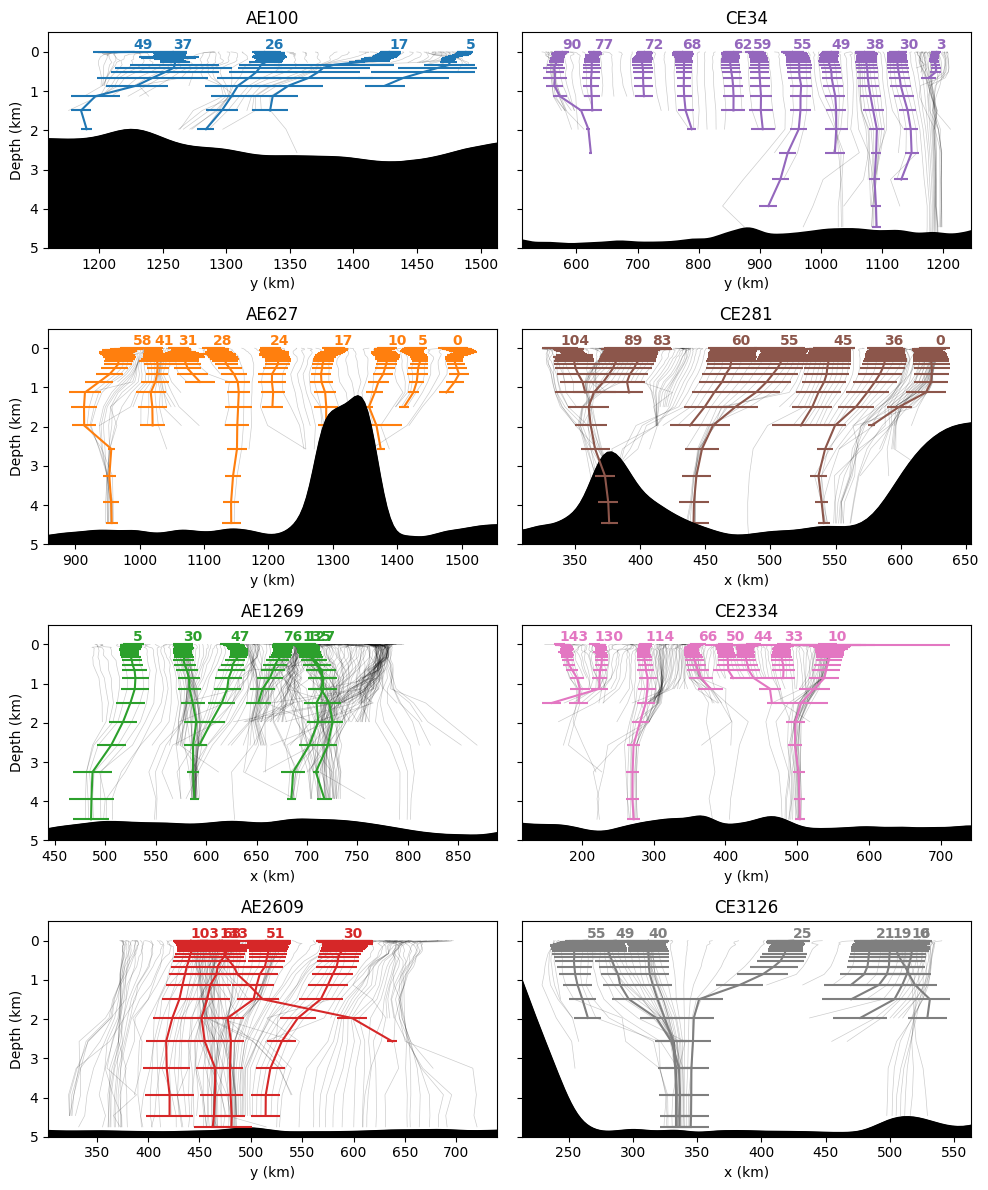

In [39]:
fig, axs = plt.subplots(4, 2, figsize=(10, 12), sharey=True)

colors_v = plt.get_cmap('tab10').colors
p = -1

for e, eddy in enumerate(sample_eddies):

    if pd.isna(eddy):
        continue

    p += 1
    eddy = int(eddy)

    ax = axs[e % 4, e // 4]  # <-- keep original layout

    flagx = eddy in [3126, 1269, 281]
    coord = 'xc' if flagx else 'yc'
    xlabel = 'x (km)' if flagx else 'y (km)'
    clr = colors_v[e % len(colors_v)]

    dic = dic_sample[f'Eddy{eddy}']

    dfs = [
        df0 for df0 in dic.values()
        if len(df0) and not df0.isna().all().all()
    ]
    if not dfs:
        continue

    df_all = pd.concat(dfs, ignore_index=True)
    x_mean = df_all.xc.mean()
    y_mean = df_all.yc.mean()

    for d, (day, df) in enumerate(dic.items()):

        if df.empty:
            continue

        depth = df.Depth.abs() / 1e3

        # background trajectories
        ax.plot(df[coord], depth, lw=0.5, color='k', alpha=0.2, zorder=-1)

        if day not in days_p[p]:
            continue

        if flagx:
            zorder = 0 if df.iloc[-1].yc > y_mean else 2
        else:
            zorder = 2 if df.iloc[-1].xc > x_mean else 0

        # highlighted trajectories
        ax.plot(df[coord], depth, color=clr, zorder=zorder)

        # Rc bars
        for _, row in df.iterrows():
            Rc = row.Rc / 7
            c = row.xc if flagx else row.yc
            z = abs(row.Depth) / 1e3
            ax.hlines(z, c - Rc, c + Rc, color=clr, zorder=zorder)

        # day label
        ax.text(df[coord].iloc[0], -0.08, d, color=clr, fontweight='bold')

    ax.set_xlabel(xlabel)
    xlim = ax.get_xlim()

    # bathymetry
    if flagx:
        jc = np.argmin(np.abs(y_grid - y_mean))
        ax.plot(x_grid, h[:, jc] / 1e3, 'k', zorder=1)
        ax.fill_between(x_grid, h[:, jc] / 1e3, 10, color='k', zorder=1)
    else:
        ic = np.argmin(np.abs(x_grid - x_mean))
        ax.plot(y_grid, h[ic, :] / 1e3, 'k', zorder=1)
        ax.fill_between(y_grid, h[ic, :] / 1e3, 10, color='k', zorder=1)

    ylim = ax.get_ylim()

    cyc = df_eddies.loc[df_eddies.Eddy == eddy, 'Cyc'].iloc[0]
    ax.set_title(f'{cyc}{eddy}')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    if e < 4:
        ax.set_ylabel('Depth (km)')

axs[0, 0].invert_yaxis()
axs[0, 0].set_ylim(5, -0.5)

plt.tight_layout()
plt.show()


##### Surface

#### Propogation

#### Volitility

In [12]:
diffs_x, diffs_y = {}, {}

depth_int = 10
max_depth = 4740
target_depths = np.arange(0, max_depth + depth_int, depth_int)
full_idx = target_depths[:-1]

for eddy in sample_eddies:

    if pd.isna(eddy):
        continue

    eddy_id = int(eddy)
    eddy_key = f'Eddy{eddy_id}'

    for d, (day, df0) in enumerate(dic_sample[eddy_key].items()):

        key = f'{eddy_key}_Day{d}'

        if df0.empty or len(df0) < 2:
            diffs_x[key] = pd.Series(np.nan, index=full_idx)
            diffs_y[key] = pd.Series(np.nan, index=full_idx)
            continue

        df = (
            df0.assign(Depth=df0.Depth.abs())
               .query('Depth <= @max_depth')
               .sort_values('Depth')
        )

        if len(df) < 2:
            diffs_x[key] = pd.Series(np.nan, index=full_idx)
            diffs_y[key] = pd.Series(np.nan, index=full_idx)
            continue

        x_i = np.interp(target_depths, df.Depth, df.xc, left=np.nan, right=np.nan)
        y_i = np.interp(target_depths, df.Depth, df.yc, left=np.nan, right=np.nan)

        diffs_x[key] = pd.Series(np.diff(x_i), index=full_idx)
        diffs_y[key] = pd.Series(np.diff(y_i), index=full_idx)

df_X_all = pd.DataFrame(diffs_x).reindex(full_idx)
df_Y_all = pd.DataFrame(diffs_y).reindex(full_idx)

df_data = pd.DataFrame(index=full_idx)

for eddy in sample_eddies:

    if pd.isna(eddy):
        continue

    eddy_id = int(eddy)
    eddy_key = f'Eddy{eddy_id}'

    cols = [c for c in df_X_all.columns if c.startswith(f'{eddy_key}_Day')]

    df_data[f'x_{eddy_key}_mean'] = df_X_all[cols].mean(axis=1)
    df_data[f'x_{eddy_key}_std'] = df_X_all[cols].std(axis=1)

    df_data[f'y_{eddy_key}_mean'] = df_Y_all[cols].mean(axis=1)
    df_data[f'y_{eddy_key}_std'] = df_Y_all[cols].std(axis=1)


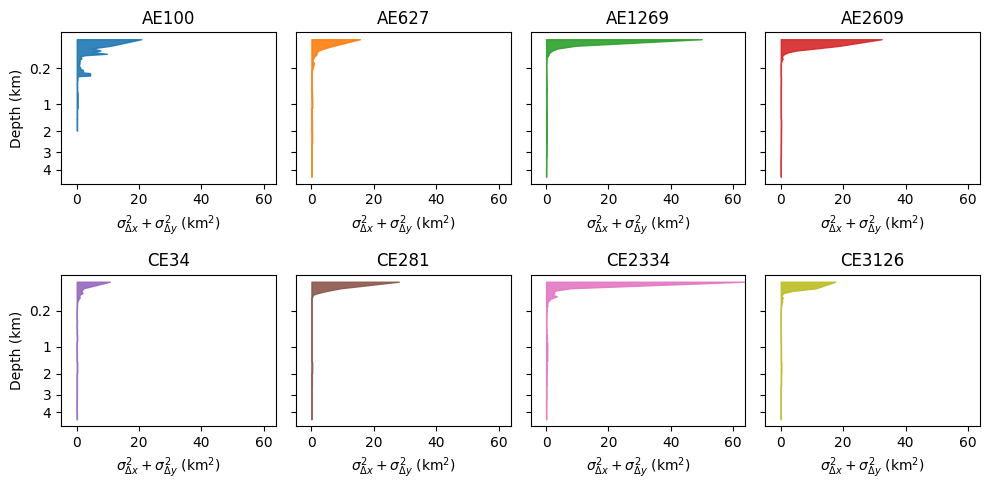

In [13]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5), sharey=True)

gamma = 0.5
depth_real = df_data.index.values / 1e3
dmin = depth_real.min()

stretch = lambda d: (d - dmin) ** gamma

tick_depths = np.array([0.2, 1, 2, 3, 4])
tick_pos = stretch(tick_depths)

xmax = 0

for e, eddy in enumerate(sample_eddies):

    if pd.isna(eddy):
        continue

    eddy_id = int(eddy)
    eddy_key = f'Eddy{eddy_id}'

    ax = axs[e // 4, e % 4]
    clr = colors[e % len(colors)]

    cyc = df_eddies.loc[df_eddies.Eddy == eddy_id, 'Cyc'].iloc[0]
    ax.set_title(f'{cyc}{eddy_id}')

    x_std = df_data[f'x_{eddy_key}_std']
    y_std = df_data[f'y_{eddy_key}_std']

    total_var = x_std**2 + y_std**2
    xmax = max(xmax, np.nanmax(total_var))

    ax.fill_betweenx(
        stretch(depth_real),
        0,
        total_var,
        color=clr,
        alpha=0.9
    )

for ax in axs.flat:
    ax.set_xlim(-5, xmax)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f'{d:g}' for d in tick_depths])
    ax.set_xlabel(r'$\sigma_{\Delta x}^2+\sigma_{\Delta y}^2$ (km$^2$)')

axs[0, 0].set_ylabel('Depth (km)')
axs[1, 0].set_ylabel('Depth (km)')
axs[0, 0].invert_yaxis()

plt.tight_layout()
plt.show()


#### Velocity Field

In [14]:
def quad_solver_x(xc, yc, q11, q12, q22, Rc, y0):
    a = q11
    b = -2*q11*xc + 2*q12*(y0 - yc)
    c = q11*xc**2 - 2*q12*xc*(y0 - yc) + q22*(y0 - yc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return root1, root2

def quad_solver_y(xc, yc, q11, q12, q22, Rc, x0):
    a = q22
    b = 2*q12*(x0 - xc)
    c = q11*(x0 - xc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    dy1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    dy2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return yc + dy1, yc + dy2
    

In [15]:
day_idx_p = [26, 17, 5, 51, 
             68, 89, 114, 40]




/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_999857/1326891384.py:7: RuntimeWarning: invalid value encountered in sqrt
  root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_999857/1326891384.py:8: RuntimeWarning: invalid value encountered in sqrt
  root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_999857/1326891384.py:7: RuntimeWarning: invalid value encountered in sqrt
  root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_999857/1326891384.py:8: RuntimeWarning: invalid value encountered in sqrt
  root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)


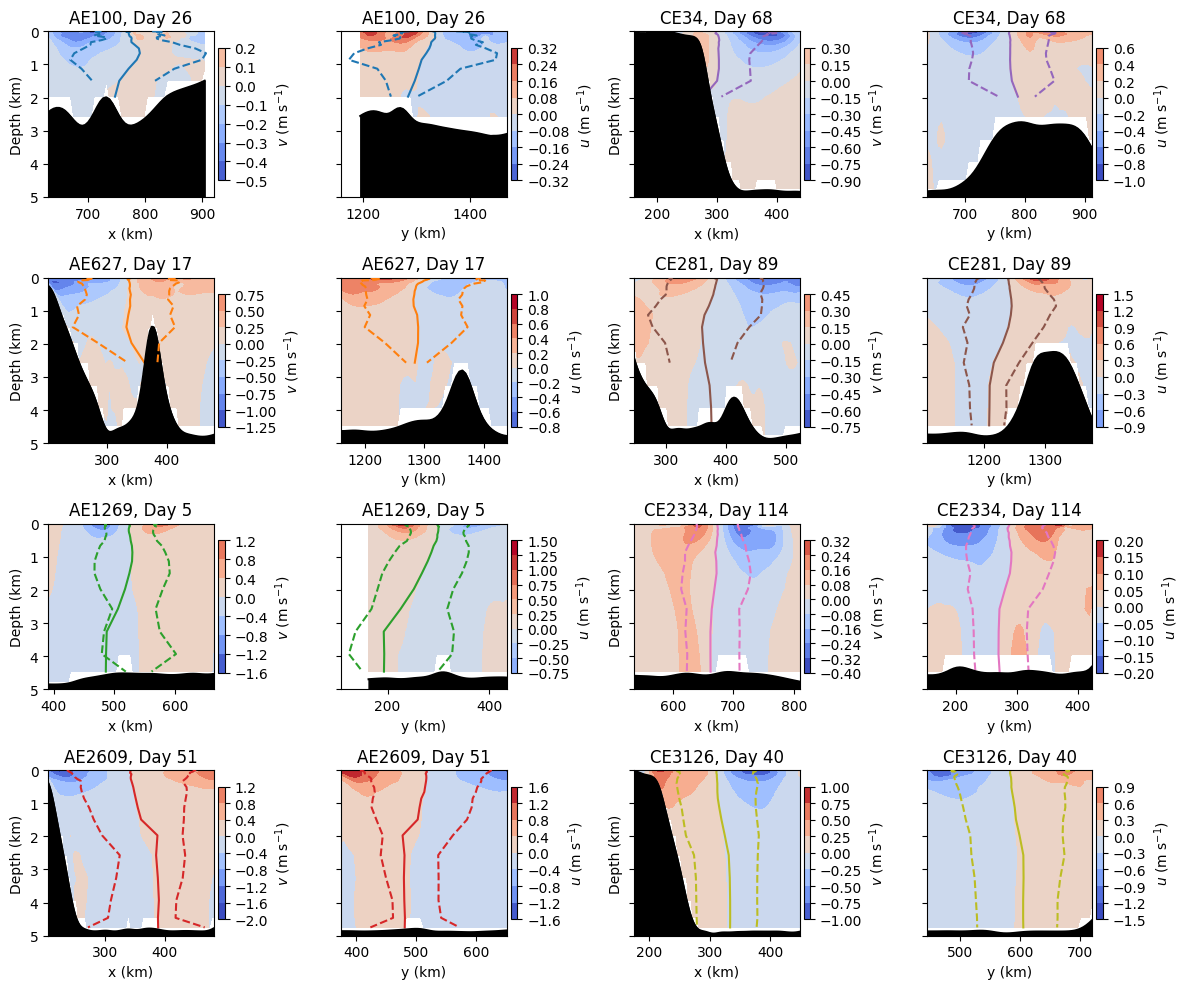

In [16]:
fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharey=True)

fnumber_old = None
u_raw = v_raw = ocean_time = None

for e, (eddy, day_idx) in enumerate(zip(sample_eddies, day_idx_p)):

    if pd.isna(eddy):
        continue

    eddy = int(eddy)
    row = df_eddies.loc[df_eddies.Eddy == eddy].iloc[0]
    cyc = row.Cyc

    ax0 = axs[e % 4, (e // 4) * 2]
    ax1 = axs[e % 4, (e // 4) * 2 + 1]

    r = 200 if eddy in [1780, 1978] else 140
    clr = colors[e % len(colors)]

    dic = dic_sample[f'Eddy{eddy}']
    day_key = list(dic.keys())[day_idx]
    day = int(day_key[3:])
    df = dic[day_key].copy()

    day_rel = day - row.Day
    title = f'{cyc}{eddy}, Day {day_rel}'
    ax0.set_title(title)
    ax1.set_title(title)

    fname = df_eddies.loc[
        (df_eddies.Eddy == eddy) & (df_eddies.Day == day), 'fname'
    ].iloc[0]

    fnumber = fname[-8:-3]

    if fnumber != fnumber_old:
        u_raw = np.load(f'/srv/scratch/z5297792/Climatology/u_v/u_{fnumber}.npy').astype(float)
        v_raw = np.load(f'/srv/scratch/z5297792/Climatology/u_v/v_{fnumber}.npy').astype(float)

        u_raw[np.abs(u_raw) > 1e30] = np.nan
        v_raw[np.abs(v_raw) > 1e30] = np.nan

        with nc.Dataset(fname) as dataset:
            ocean_time = dataset.variables['ocean_time'][:].data / 86400

        fnumber_old = fnumber

    t_rel = np.where(ocean_time == day)[0][0]
    u_t = u_raw[:, :, :, t_rel]
    v_t = v_raw[:, :, :, t_rel]

    xc_surf, yc_surf = df.iloc[0][['xc', 'yc']]

    ic = np.argmin(np.abs(x_grid - xc_surf))
    jc = np.argmin(np.abs(y_grid - yc_surf))

    x_mask = np.abs(x_grid - xc_surf) < r
    y_mask = np.abs(y_grid - yc_surf) < r

    z_km = np.abs(z_r[150, 150, :]) / 1e3
    depth_km = df.Depth.abs() / 1e3

    vmax_v = np.nanmax(np.abs(v_t[x_mask, jc, :]))
    vmax_u = np.nanmax(np.abs(u_t[ic, y_mask, :]))

    im0 = ax0.contourf(
        x_grid[x_mask], z_km, v_t[x_mask, jc, :].T,
        cmap='coolwarm', vmin=-vmax_v, vmax=vmax_v, zorder=0
    )

    ax0.plot(df.xc, depth_km, color=clr)

    roots_x = np.array([
        quad_solver_x(
            d.xc, d.yc, d.Q[0, 0], d.Q[1, 0], d.Q[1, 1], d.Rc, y_grid[jc]
        )
        for _, d in df.iterrows()
    ])

    zorder_x = 1 if df.iloc[-1].yc > y_grid[jc] else 3
    ax0.plot(roots_x[:, 0], depth_km, color=clr, ls='--', zorder=zorder_x)
    ax0.plot(roots_x[:, 1], depth_km, color=clr, ls='--', zorder=zorder_x)

    ax0.plot(x_grid[x_mask], h[x_mask, jc] / 1e3, 'k', zorder=2)
    ax0.fill_between(x_grid[x_mask], h[x_mask, jc] / 1e3, 10, color='k', zorder=2)

    ax0.set_xlabel('x (km)')
    ax0.set_ylabel('Depth (km)')

    cbar0 = fig.colorbar(im0, ax=ax0, pad=0.02, shrink=0.8)
    cbar0.set_label(r'$v$ (m s$^{-1}$)')

    im1 = ax1.contourf(
        y_grid[y_mask], z_km, u_t[ic, y_mask, :].T,
        cmap='coolwarm', vmin=-vmax_u, vmax=vmax_u, zorder=0
    )

    ax1.plot(df.yc, depth_km, color=clr)

    roots_y = np.array([
        quad_solver_y(
            d.xc, d.yc, d.Q[0, 0], d.Q[1, 0], d.Q[1, 1], d.Rc, x_grid[ic]
        )
        for _, d in df.iterrows()
    ])

    zorder_y = 1 if df.iloc[-1].xc < x_grid[ic] else 3
    ax1.plot(roots_y[:, 0], depth_km, color=clr, ls='--', zorder=zorder_y)
    ax1.plot(roots_y[:, 1], depth_km, color=clr, ls='--', zorder=zorder_y)

    ax1.plot(y_grid[y_mask], h[ic, y_mask] / 1e3, 'k', zorder=2)
    ax1.fill_between(y_grid[y_mask], h[ic, y_mask] / 1e3, 10, color='k', zorder=2)

    ax1.set_xlabel('y (km)')
    ax1.set_ylim(0, 5)

    cbar1 = fig.colorbar(im1, ax=ax1, pad=0.02, shrink=0.8)
    cbar1.set_label(r'$u$ (m s$^{-1}$)')

axs[0, 0].invert_yaxis()
plt.tight_layout()
plt.show()



### Plan View

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

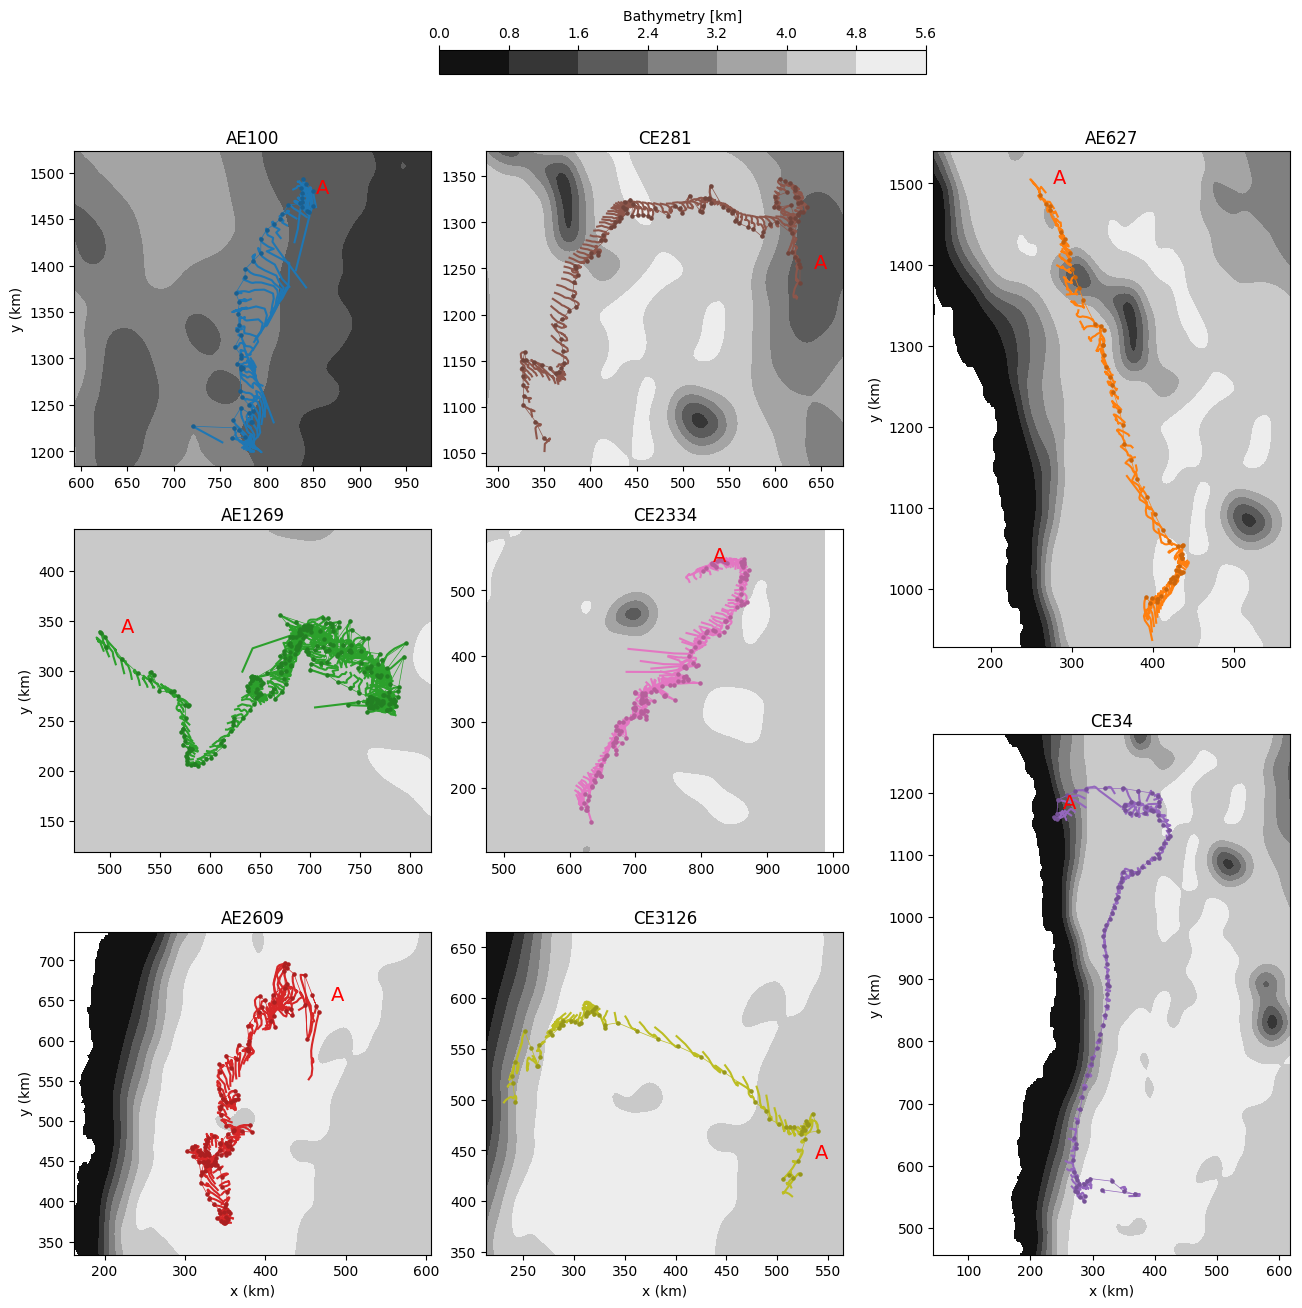

In [17]:
from matplotlib.colors import to_rgb
def darken(color, factor=0.7):
    r, g, b = to_rgb(color)
    return (r*factor, g*factor, b*factor)

fig = plt.figure(figsize=(13, 13), constrained_layout=True)
gs = fig.add_gridspec(6, 3)

gap = 5
mappable = None
s = 5

# slots for all non-special eddies on a 6x3 grid (left two columns)
# roughly mimics a 3x2 layout: rows 0,2,4
normal_slots = [
    (0, 0), (2, 0), (4, 0),
    (0, 1), (2, 1), (4, 1),
]

k = 0
axes_list = []
for e, eddy in enumerate(sample_eddies):

    # eddy 1 and 4 get tall panels in the right column
    if e == 1:
        ax = fig.add_subplot(gs[0:3, 2])   # top-right, 1.5 "rows" tall
        axes_list.append(ax)
        col = 2
        row = 0
        is_tall = True
        ax.set_ylabel('y (km)')
    elif e == 4:
        ax = fig.add_subplot(gs[3:6, 2])   # bottom-right, 1.5 "rows" tall
        axes_list.append(ax)
        col = 2
        row = 4
        is_tall = True
        ax.set_xlabel('x (km)')
        ax.set_ylabel('y (km)')
    else:
        row, col = normal_slots[k]
        k += 1
        ax = fig.add_subplot(gs[row:row+2, col])
        axes_list.append(ax)
        is_tall = False

    df = df_eddies[df_eddies.Eddy == eddy]
    m = ax.contourf(X_grid, Y_grid, np.where(mask_rho, h/1e3, np.nan), cmap='gray')
    if mappable is None:
        mappable = m

    df_eddy = df_eddies[df_eddies.Eddy == eddy]
    ax.plot(df_eddy.xc, df_eddy.yc, color=colors[e], linewidth=.5, zorder=1)
    flg = True
    for d, day in enumerate(df['Day'].unique()):
        data = df[df.Day == day]

        plot_data = df_eddies[(df_eddies.Eddy == eddy) & (df_eddies['Day'] == int(day))]
        x0, y0 = plot_data.iloc[0].xc, plot_data.iloc[0].yc
        
        df_vert = dic_sample[f'Eddy{eddy}'][f'Day{day}'].copy()
        df_vert = df_vert[df_vert.Depth.abs() < 1000]
        
        cyc = df_eddies[df_eddies.Eddy == eddy].Cyc.iloc[0]

        if len(df_vert):
            if flg:
                ax.plot(df_vert.xc, df_vert.yc, color=colors[e], zorder=2,
                    label=f'{cyc}{eddy}')
                flg = False
            else:
                ax.plot(df_vert.xc, df_vert.yc, color=colors[e], zorder=2)
            ax.scatter(x0, y0, color=darken(colors[e % len(colors)], 0.8),
                   s=s, zorder=3)
        else:
            ax.scatter(x0, y0, color=darken(colors[e % len(colors)], 0.8),
                       s=15, zorder=3, facecolors='none')

    if eddy==1602:
        a, b = -2.5, -2.5
    elif eddy==1780:
        a, b = 1, 0
    elif eddy==182:
        a, b = -1.5, 0
    elif eddy==871:
        a, b = .5, 0
    else:
        a, b = 1, 1
        
    ax.text(df_eddy.iloc[0].xc+a*15, df_eddy.iloc[0].yc+b*15, 'A',
            color='r', fontsize=14)
    cyc = df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc
    ax.axis('equal'); ax.set_title(f'{cyc}{eddy}')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    # axis labels: left column gets y, bottom band gets x
    if col == 0:
        ax.set_ylabel('y (km)')
    # bottom "row" for small plots (row==4) and the lower tall panel (eddy 4)
    if (not is_tall and row == 4) or (is_tall and e == 4):
        ax.set_xlabel('x (km)')

cbar = fig.colorbar(mappable, ax=axes_list, location='top', shrink=0.4)
cbar.set_label('Bathymetry [km]')
